In [1]:
!pip install yfinance

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
import math
import pandas_datareader as datareader
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
plt.style.use('fivethirtyeight')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset_train = pd.read_csv("/content/drive/MyDrive/se sem4/AI and ML/Assignment/Datasets/AAPL.csv")

In [4]:
dataset_train

,Date,Open,High,Low,Close,Volume
0,4/1/2010,7.62,7.66,7.58,7.64,493728704
1,5/1/2010,7.66,7.70,7.62,7.66,601904640
2,6/1/2010,7.66,7.69,7.53,7.53,552158912
3,7/1/2010,7.56,7.57,7.47,7.52,477129760
4,8/1/2010,7.51,7.57,7.47,7.57,447876768
...,...,...,...,...,...,...
3193,8/9/2022,154.60,156.34,152.72,154.45,83838328
3194,9/9/2022,155.41,157.78,154.76,157.37,67565208
3195,12/9/2022,159.53,164.25,159.42,163.43,102847776
3196,13/9/2022,159.79,160.52,153.41,153.84,121387072


In [5]:
from sklearn.preprocessing import MinMaxScaler
trainset = dataset_train.iloc[:,1:2].values
sc = MinMaxScaler(feature_range = (0,1))
training_scaled = sc.fit_transform(trainset)
training_scaled

array([[0.00426718],
       [0.00449477],
       [0.00449477],
       ...,
       [0.86857078],
       [0.87005007],
       [0.84120391]])

In [6]:
x_train = []
y_train = []

for i in range(1,3198):
  x_train.append(training_scaled[i-1:i,0])
  y_train.append(training_scaled[i,0])
x_train,y_train = np.array(x_train),np.array(y_train)

x_train.shape

(3197, 1)

In [7]:
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [9]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

regressor = Sequential()
regressor.add(LSTM(units = 50,return_sequences = True, input_shape = (x_train.shape[1],1)))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units = 1))
regressor.compile(optimizer = 'adam',loss = 'mean_squared_error')
regressor.fit(x_train,y_train,epochs = 100, batch_size = 32)

Epoch 1/100
100/100 [==============================] - 5s 5ms/step - loss: 0.0482
Epoch 2/100
100/100 [==============================] - 1s 7ms/step - loss: 0.0024
Epoch 3/100
100/100 [==============================] - 1s 8ms/step - loss: 0.0019
Epoch 4/100
100/100 [==============================] - 1s 8ms/step - loss: 0.0016
Epoch 5/100
100/100 [==============================] - 1s 9ms/step - loss: 0.0015
Epoch 6/100
100/100 [==============================] - 1s 8ms/step - loss: 0.0014
Epoch 7/100
100/100 [==============================] - 1s 7ms/step - loss: 0.0012
Epoch 8/100
100/100 [==============================] - 0s 4ms/step - loss: 0.0013
Epoch 9/100
100/100 [==============================] - 0s 4ms/step - loss: 0.0013
Epoch 10/100
100/100 [==============================] - 0s 5ms/step - loss: 0.0010
Epoch 11/100
100/100 [==============================] - 0s 4ms/step - loss: 0.0010
Epoch 12/100
100/100 [==============================] - 0s 4ms/step - loss: 0.0011
Epoch 13/100


In [10]:
dataset_test = pd.read_csv("/content/drive/MyDrive/se sem4/AI and ML/Assignment/Datasets/AAPL RealData.csv")

In [11]:
real_stock_price = dataset_test.iloc[:,1:2].values
dataset_total = pd.concat((dataset_train['Open'],dataset_test['Open']),axis = 0)
dataset_total

0         7.62
1         7.66
2         7.66
3         7.56
4         7.51
         ...  
3193    154.60
3194    155.41
3195    159.53
3196    159.79
3197    154.72
Name: Open, Length: 6396, dtype: float64

In [12]:
inputs = dataset_total[len(dataset_total) - len(dataset_test)-3000:].values
inputs

array([ 10.98,  11.37,  10.84, ..., 159.53, 159.79, 154.72])

In [13]:
inputs = inputs.reshape(-1,1)
inputs


array([[ 10.98],
       [ 11.37],
       [ 10.84],
       ...,
       [159.53],
       [159.79],
       [154.72]])

In [14]:
inputs = sc.transform(inputs)
inputs.shape

(6198, 1)

In [23]:
x_test = []
for i in range(1,3198):
    x_test.append(inputs[i-1:i,0])
x_test = np.array(x_test)
x_test.shape


(3197, 1)

In [24]:
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
x_test.shape

(3197, 1, 1)

In [25]:
predicted_price = regressor.predict(x_test)
predicted_price = sc.inverse_transform(predicted_price)
predicted_price

100/100 [==============================] - 0s 2ms/step


array([[13.064526],
       [13.416939],
       [12.93811 ],
       ...,
       [12.658366],
       [12.676409],
       [12.829795]], dtype=float32)

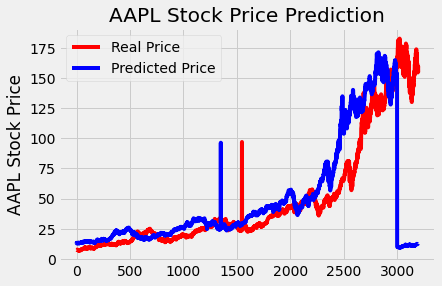

In [26]:
plt.plot(real_stock_price,color = 'red', label = 'Real Price')
plt.plot(predicted_price, color = 'blue', label = 'Predicted Price')
plt.title('AAPL Stock Price Prediction')
plt.ylabel('AAPL Stock Price')
plt.legend()
plt.show()